<a href="https://colab.research.google.com/github/HitenKumar786/Stock-Price-Prediction-Using-LSTM-GRU/blob/main/AI_And_Neural_Network.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# 1. Import Required Libraries

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler

import warnings
warnings.filterwarnings('ignore')

from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout

from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import GRU
import time


# Set plotting style
plt.style.use('ggplot')

In [2]:
# 2. Load Dataset

df = pd.read_csv("/content/Stock_Price_Data_[3921] (1).csv")
df.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,1980-12-12,0.513393,0.515625,0.513393,0.513393,0.406782,117258400
1,1980-12-15,0.488839,0.488839,0.486607,0.486607,0.385558,43971200
2,1980-12-16,0.453125,0.453125,0.450893,0.450893,0.357260,26432000
3,1980-12-17,0.462054,0.464286,0.462054,0.462054,0.366103,21610400
4,1980-12-18,0.475446,0.477679,0.475446,0.475446,0.376715,18362400


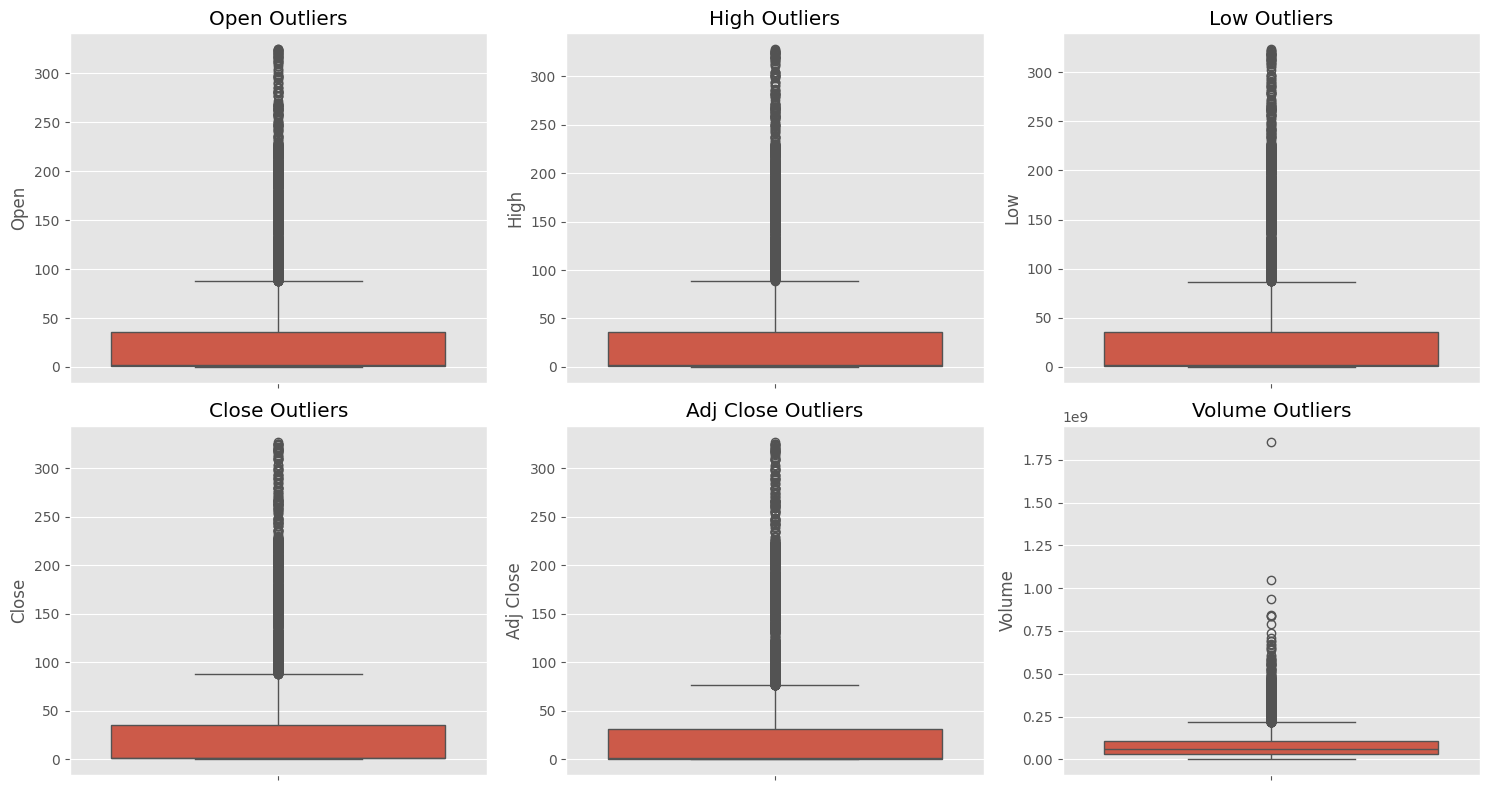

In [3]:

# Boxplots for All Numerical Features

# Select numerical columns
numerical_cols = ['Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume']

# Create figure
plt.figure(figsize=(15, 8))

# Generate boxplots
for i, col in enumerate(numerical_cols, 1):

    plt.subplot(2, 3, i)

    sns.boxplot(y=df[col])

    plt.title(f'{col} Outliers')

# Adjust layout
plt.tight_layout()

# Save high-quality image
plt.savefig(
    'All_Features_Boxplots.png',
    dpi=1080,
    bbox_inches='tight'
)

plt.show()

In [4]:
# 3. Dataset Shape

print("\nDataset Shape")
print(df.shape)

print("\nRows :", df.shape[0])
print("Columns :", df.shape[1])


Dataset Shape
(9909, 7)

Rows : 9909
Columns : 7


In [5]:
# 4. Column Names

print("\nCloumns")

for col in df.columns:
  print(col)


Cloumns
Date
Open
High
Low
Close
Adj Close
Volume


In [6]:
# 5. Dataset Information
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9909 entries, 0 to 9908
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       9909 non-null   object 
 1   Open       9909 non-null   float64
 2   High       9909 non-null   float64
 3   Low        9909 non-null   float64
 4   Close      9909 non-null   float64
 5   Adj Close  9909 non-null   float64
 6   Volume     9909 non-null   int64  
dtypes: float64(5), int64(1), object(1)
memory usage: 542.0+ KB
None


In [7]:
#6. Checking Null values
df.isnull().sum()

,0
Date,0
Open,0
High,0
Low,0
Close,0
Adj Close,0
Volume,0


In [8]:
# 7. Statistical Summary

print(df.describe())

              Open         High          Low        Close    Adj Close  \
count  9909.000000  9909.000000  9909.000000  9909.000000  9909.000000   
mean     32.606849    32.936079    32.277560    32.618030    30.576570   
std      58.415759    59.001576    57.883037    58.471899    56.746275   
min       0.198661     0.198661     0.196429     0.196429     0.155638   
25%       1.071429     1.089286     1.048571     1.071429     0.917643   
50%       1.729286     1.758929     1.696429     1.732143     1.466154   
75%      35.799999    36.265713    35.328571    35.761429    31.042374   
max     324.739990   327.850006   323.350006   327.200012   327.200012   

             Volume  
count  9.909000e+03  
mean   8.582916e+07  
std    8.597195e+07  
min    3.472000e+05  
25%    3.304230e+07  
50%    5.766490e+07  
75%    1.069992e+08  
max    1.855410e+09  


In [9]:
# 8. Check Duplicate Rows
print(df.duplicated().sum())

0


In [10]:
# 9. Convert Date Column

df['Date']  = pd.to_datetime(df['Date'])
df.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,1980-12-12,0.513393,0.515625,0.513393,0.513393,0.406782,117258400
1,1980-12-15,0.488839,0.488839,0.486607,0.486607,0.385558,43971200
2,1980-12-16,0.453125,0.453125,0.450893,0.450893,0.357260,26432000
3,1980-12-17,0.462054,0.464286,0.462054,0.462054,0.366103,21610400
4,1980-12-18,0.475446,0.477679,0.475446,0.475446,0.376715,18362400


In [11]:
# 10. Sort Dataset

df = df.sort_values('Date')

df.reset_index(drop=True,
               inplace=True)
df.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,1980-12-12,0.513393,0.515625,0.513393,0.513393,0.406782,117258400
1,1980-12-15,0.488839,0.488839,0.486607,0.486607,0.385558,43971200
2,1980-12-16,0.453125,0.453125,0.450893,0.450893,0.357260,26432000
3,1980-12-17,0.462054,0.464286,0.462054,0.462054,0.366103,21610400
4,1980-12-18,0.475446,0.477679,0.475446,0.475446,0.376715,18362400


In [12]:
# 11. Check Data Types
print(df.dtypes)

Date         datetime64[ns]
Open                float64
High                float64
Low                 float64
Close               float64
Adj Close           float64
Volume                int64
dtype: object


In [13]:
# 12. Check Dataset Again
print(df.head())
print(df.tail())

        Date      Open      High       Low     Close  Adj Close     Volume
0 1980-12-12  0.513393  0.515625  0.513393  0.513393   0.406782  117258400
1 1980-12-15  0.488839  0.488839  0.486607  0.486607   0.385558   43971200
2 1980-12-16  0.453125  0.453125  0.450893  0.450893   0.357260   26432000
3 1980-12-17  0.462054  0.464286  0.462054  0.462054   0.366103   21610400
4 1980-12-18  0.475446  0.477679  0.475446  0.475446   0.376715   18362400
           Date        Open        High         Low       Close   Adj Close  \
9904 2020-03-26  246.520004  258.679993  246.360001  258.440002  258.440002   
9905 2020-03-27  252.750000  255.869995  247.050003  247.740005  247.740005   
9906 2020-03-30  250.740005  255.520004  249.399994  254.809998  254.809998   
9907 2020-03-31  255.600006  262.489990  252.000000  254.289993  254.289993   
9908 2020-04-01  246.500000  248.720001  239.130005  240.910004  240.910004   

        Volume  
9904  63021800  
9905  51054200  
9906  41994100  
9907  4

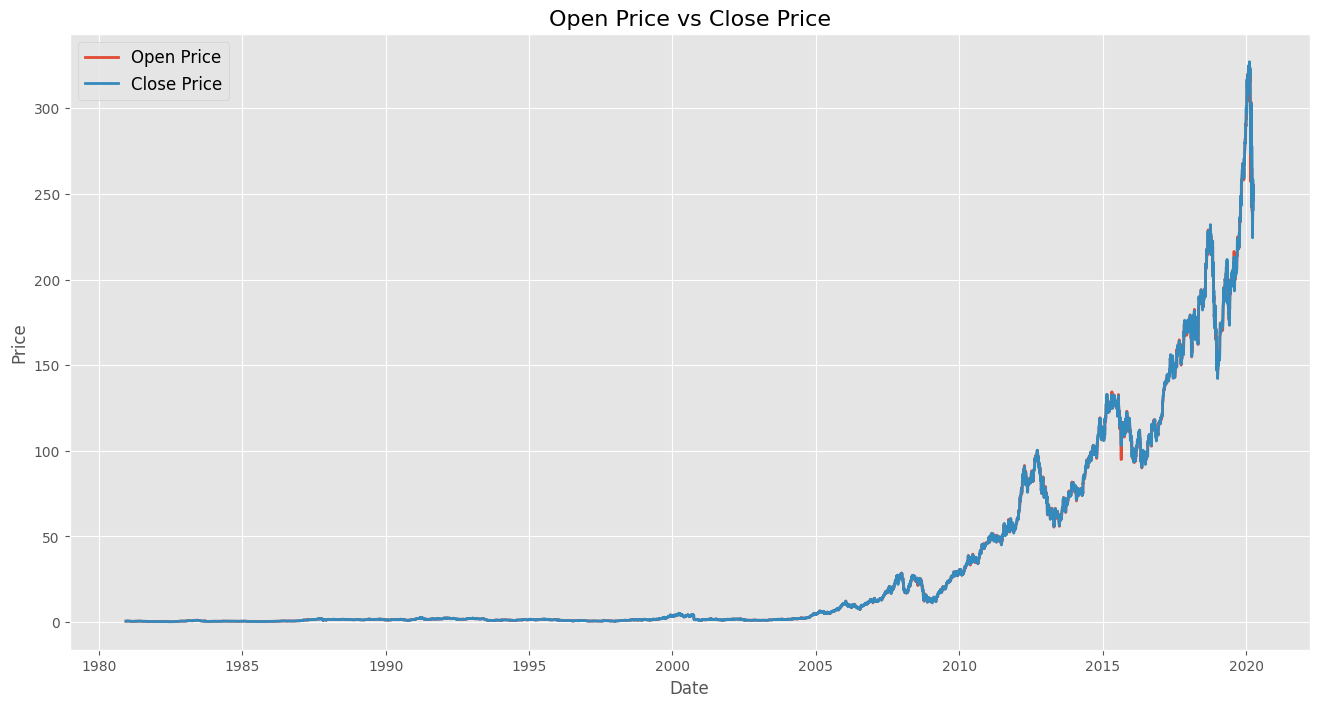

In [14]:
#13. Open Price vs Close Price

plt.figure(figsize=(16,8))

plt.plot(df['Date'],df['Open'],label='Open Price',linewidth=2)

plt.plot(df['Date'],df['Close'],label='Close Price',
         linewidth=2)

plt.title('Open Price vs Close Price', fontsize=16)

plt.xlabel('Date', fontsize=12)

plt.ylabel('Price', fontsize=12)

plt.legend(fontsize=12)

plt.grid(True)

# Save High-Quality Image
plt.savefig('Open_vs_Close.png',
            dpi=1080,
            bbox_inches='tight')

plt.show()


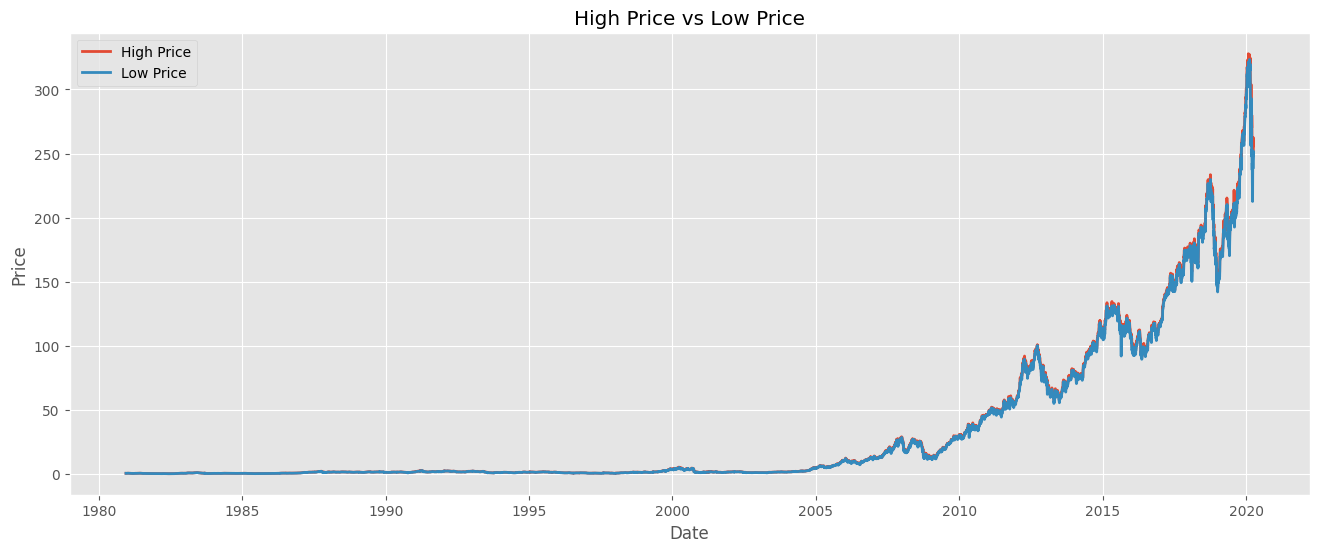

In [15]:
# High Price vs Low Price
# ============================================================

plt.figure(figsize=(16,6))

plt.plot(df['Date'],
         df['High'],
         label='High Price',
         linewidth=2)

plt.plot(df['Date'],
         df['Low'],
         label='Low Price',
         linewidth=2)

plt.title('High Price vs Low Price')

plt.xlabel('Date')

plt.ylabel('Price')

plt.legend()

plt.grid(True)
plt.savefig('Low_vs_High.png',
            dpi=1080,
            bbox_inches='tight')
plt.show()

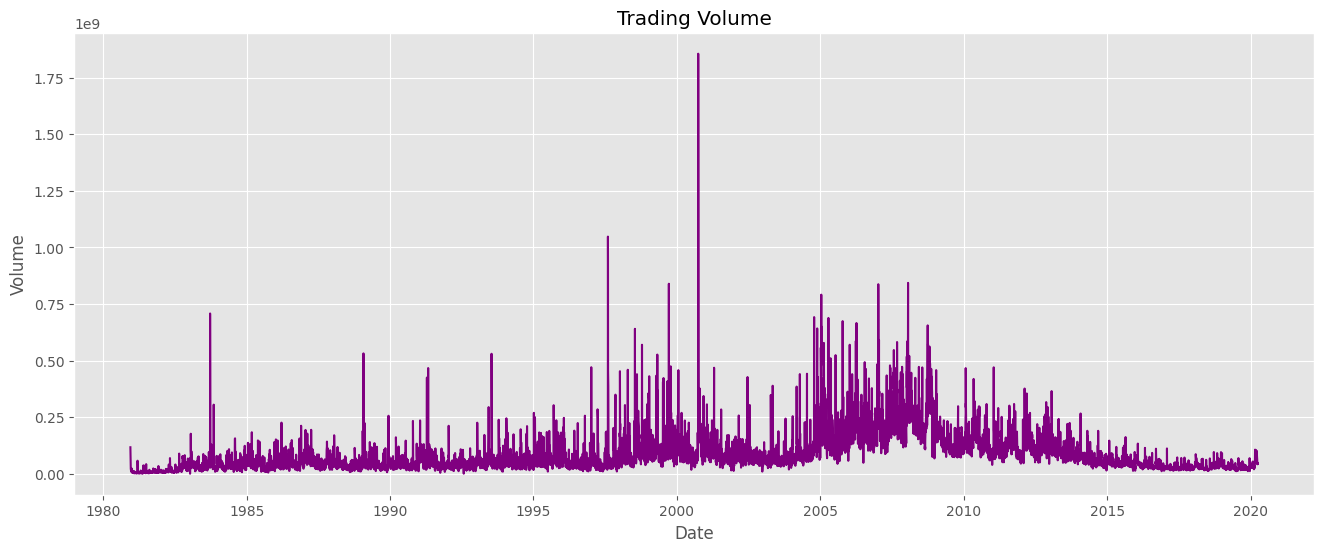

In [16]:
#Trading Volume

plt.figure(figsize=(16,6))

plt.plot(df['Date'],
         df['Volume'],
         color='purple')

plt.title("Trading Volume")

plt.xlabel("Date")

plt.ylabel("Volume")
plt.savefig('Trading Volume.png',
            dpi=1080,
            bbox_inches='tight')
plt.show()


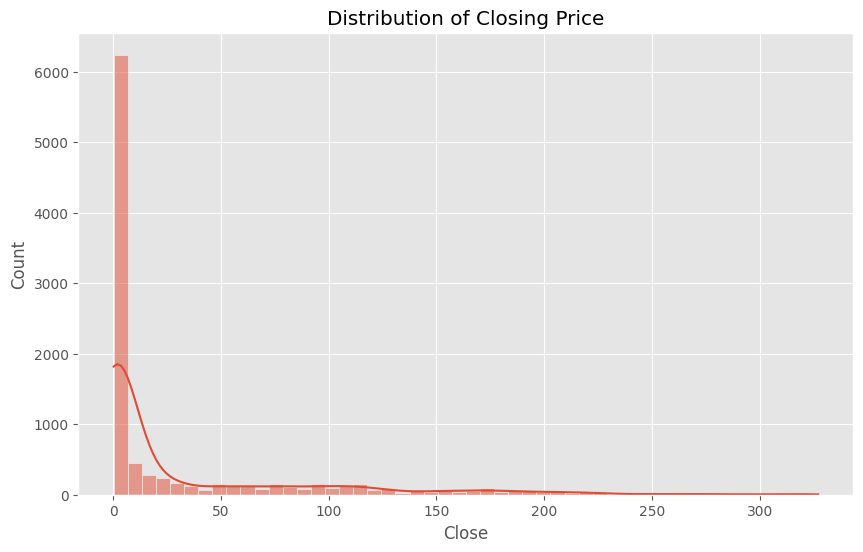

In [17]:
# Distribution of Closing Price

plt.figure(figsize=(10,6))

sns.histplot(df['Close'],
             bins=50,
             kde=True)

plt.title("Distribution of Closing Price")
plt.savefig('Distribution of Closing Price.png',
            dpi=1080,
            bbox_inches='tight')
plt.show()

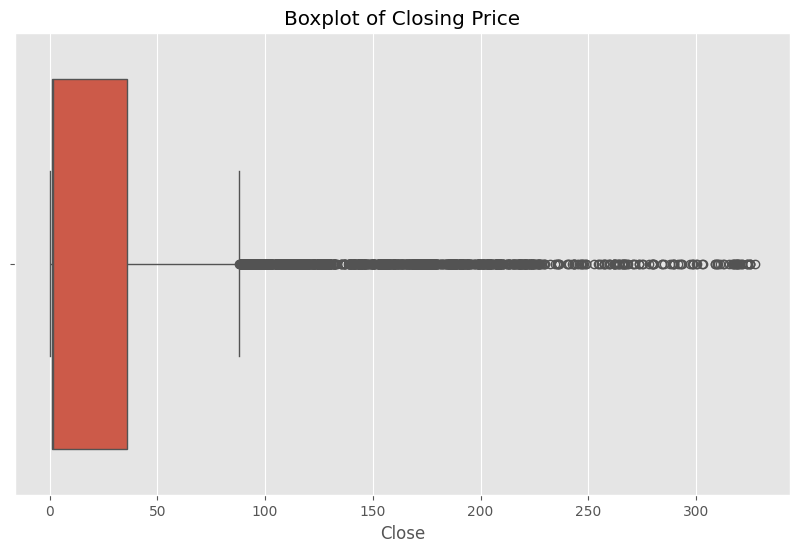

In [18]:
# Boxplot

plt.figure(figsize=(10,6))

sns.boxplot(x=df['Close'])

plt.title("Boxplot of Closing Price")

plt.savefig('boxplot.png',
            dpi=1080,
            bbox_inches='tight')
plt.show()


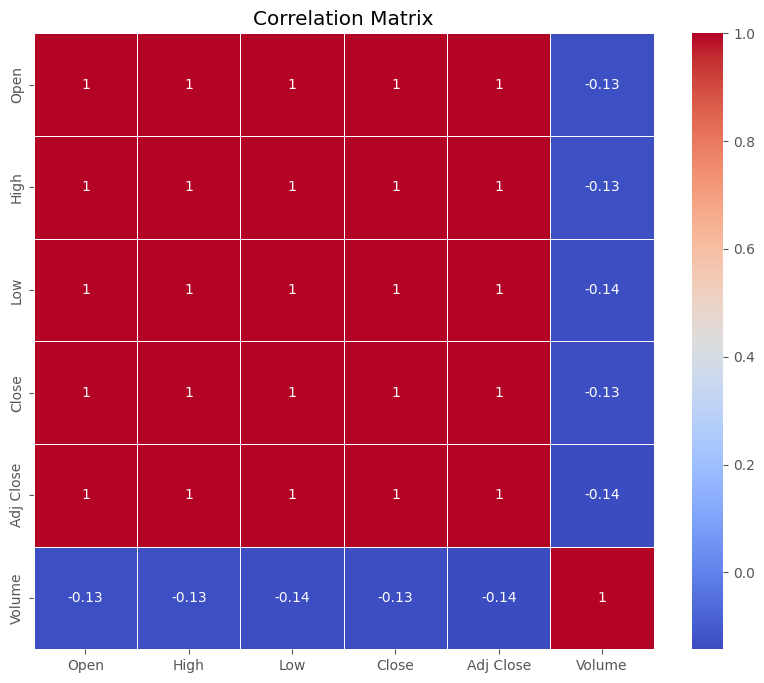

In [19]:
#Correlation Matrix


plt.figure(figsize=(10,8))

corr = df.corr(numeric_only=True)

sns.heatmap(corr,
            annot=True,
            cmap='coolwarm',
            linewidths=0.5)

plt.title("Correlation Matrix")

plt.savefig('corelation.png',
            dpi=1080,
            bbox_inches='tight')
plt.show()

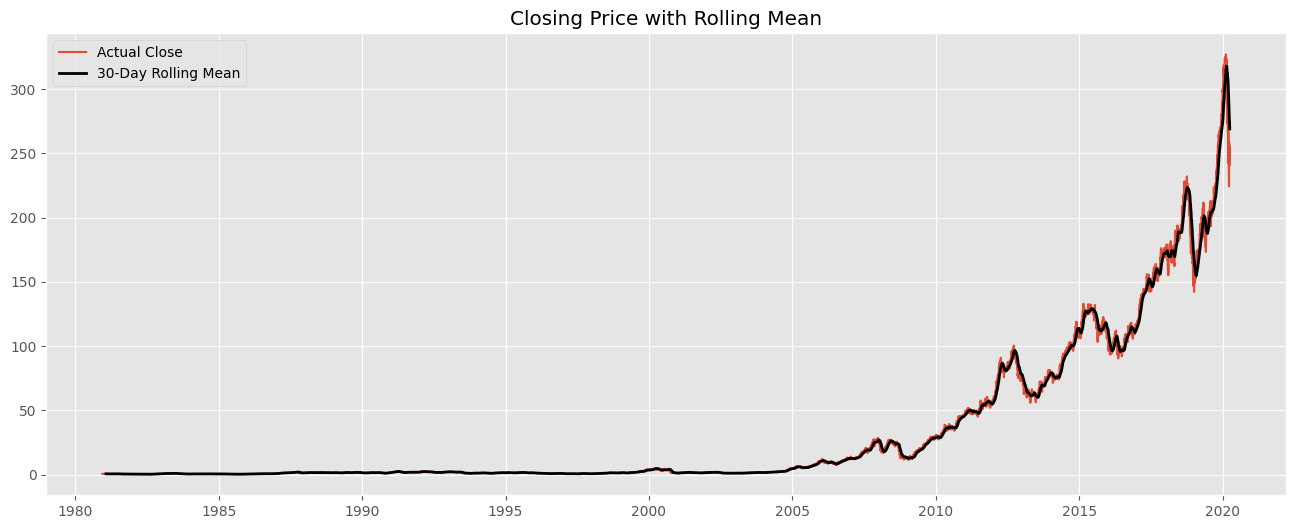

In [20]:
#Rolling Mean


rolling_mean = df['Close'].rolling(window=30).mean()

plt.figure(figsize=(16,6))

plt.plot(df['Date'],
         df['Close'],
         label="Actual Close")

plt.plot(df['Date'],
         rolling_mean,
         color='black',
         linewidth=2,
         label="30-Day Rolling Mean")

plt.legend()

plt.title("Closing Price with Rolling Mean")
plt.savefig('corelation.png',
            dpi=1080,
            bbox_inches='tight')
plt.show()

In [21]:
# We will predict Closing Price(Feature Selection)

data = df[['Close']]

print("\nSelected Feature")

print(data.head())



Selected Feature
      Close
0  0.513393
1  0.486607
2  0.450893
3  0.462054
4  0.475446


In [22]:
#Scaling

scaler = MinMaxScaler(feature_range=(0,1))

scaled_data = scaler.fit_transform(data)

print("\nData Successfully Scaled")

print(scaled_data[:10])


Data Successfully Scaled
[[0.0009693 ]
 [0.00088739]
 [0.00077817]
 [0.0008123 ]
 [0.00085326]
 [0.00094199]
 [0.00101708]
 [0.00108534]
 [0.00117408]
 [0.00133791]]


In [23]:
 #Check Shape

print("\nScaled Data Shape")

print(scaled_data.shape)


Scaled Data Shape
(9909, 1)


In [24]:
# Create Sequences
sequence_length = 60

X = []
y = []

for i in range(sequence_length, len(scaled_data)):

    X.append(
        scaled_data[i-sequence_length:i, 0]
    )

    y.append(
        scaled_data[i, 0]
    )

X = np.array(X)
y = np.array(y)

print("X Shape:", X.shape)
print("y Shape:", y.shape)

X Shape: (9849, 60)
y Shape: (9849,)


In [25]:
# Reshape for LSTM
X = np.reshape(
    X,
    (X.shape[0],
     X.shape[1],
     1)
)

print("\nReshaped X Shape")
print(X.shape)


Reshaped X Shape
(9849, 60, 1)


In [26]:
#. Train/Test Split


train_size = int(len(X) * 0.80)

X_train = X[:train_size]
X_test = X[train_size:]

y_train = y[:train_size]
y_test = y[train_size:]

print("\nTraining Data")

print(X_train.shape)
print(y_train.shape)

print("\nTesting Data")

print(X_test.shape)
print(y_test.shape)


Training Data
(7879, 60, 1)
(7879,)

Testing Data
(1970, 60, 1)
(1970,)


In [27]:
#16. Build LSTM Model

model_lstm = Sequential()


In [28]:
# Build Model
model_lstm = Sequential([

    LSTM(units=64,return_sequences=True,input_shape=(X_train.shape[1], 1)), Dropout(0.20),
    LSTM(
        units=64,
        return_sequences=False
    ),Dropout(0.20),
    Dense(25),
    Dense(1)

])

# Compile Model
model_lstm.compile(
    optimizer='adam',
    loss='mean_squared_error'
)

# Display Summary
model_lstm.summary()

# Train Model


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 64)         │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 25)             │         1,625 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            26 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 51,571 (201.45 KB)

 Trainable params: 51,571 (201.45 KB)

 Non-trainable params: 0 (0.00 B)

In [29]:
#Training Model
history_lstm = model_lstm.fit(
    X_train,
    y_train,
    validation_data=(X_test, y_test),
    epochs=50,
    batch_size=32,
    callbacks=[
        EarlyStopping(
            monitor='val_loss',
            patience=10,
            restore_best_weights=True
        )
    ],
    verbose=1
)

Epoch 1/50
247/247 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - loss: 6.8584e-05 - val_loss: 0.0013
Epoch 2/50
247/247 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 2.6368e-05 - val_loss: 4.6276e-04
Epoch 3/50
247/247 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 3.0748e-05 - val_loss: 0.0014
Epoch 4/50
247/247 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 2.6106e-05 - val_loss: 3.1455e-04
Epoch 5/50
247/247 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 2.2151e-05 - val_loss: 8.9910e-04
Epoch 6/50
247/247 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 2.2809e-05 - val_loss: 0.0035
Epoch 7/50
247/247 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 2.2723e-05 - val_loss: 0.0023
Epoch 8/50
247/247 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 2.5742e-05 - val_loss: 4.1187e-04
Epoch 9/50
247/247 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 2.6089e-05 - val_loss: 2.4958e-04
Epoch 10/50
247/247 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 2.1375e-05 - val_loss: 2.6983e-04
Epoch 11/50
247/247 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 2.3

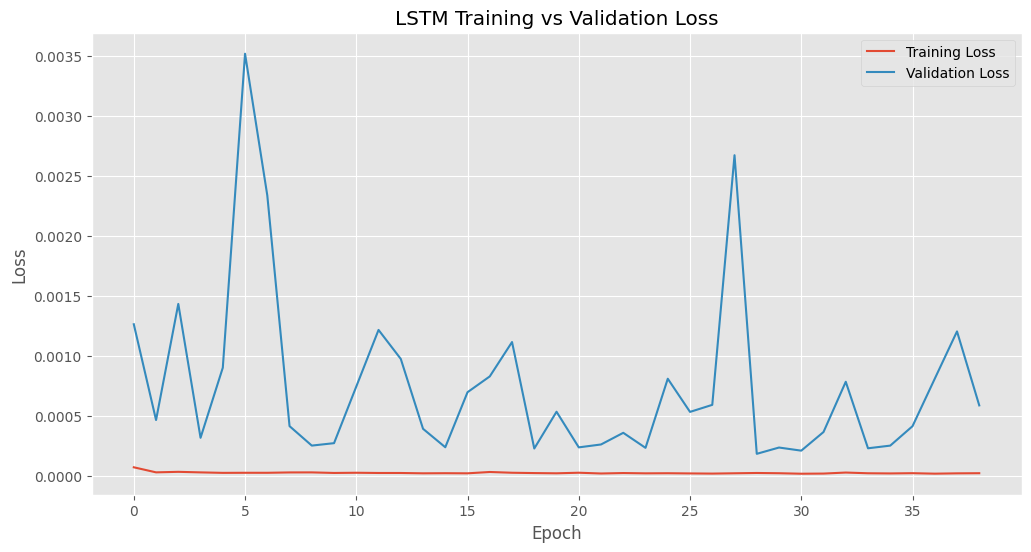

In [30]:
#Plot Training Loss


plt.figure(figsize=(12,6))

plt.plot(
    history_lstm.history['loss'],
    label='Training Loss'
)

plt.plot(
    history_lstm.history['val_loss'],
    label='Validation Loss'
)

plt.title('LSTM Training vs Validation Loss')

plt.xlabel('Epoch')

plt.ylabel('Loss')

plt.legend()

plt.grid(True)

plt.savefig(
    "LSTM_Loss_Curve.png",
    dpi=1080,
    bbox_inches='tight'
)

plt.show()

In [31]:
# Predictions

predictions_lstm = model_lstm.predict(X_test)


62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step


In [32]:
# Reverse Scaling

predictions_lstm = scaler.inverse_transform(
    predictions_lstm
)

y_test_actual = scaler.inverse_transform(
    y_test.reshape(-1,1)
)

In [33]:
# Evaluation Metrics


rmse_lstm = np.sqrt(
    mean_squared_error(
        y_test_actual,
        predictions_lstm
    )
)

mae_lstm = mean_absolute_error(
    y_test_actual,
    predictions_lstm
)

r2_lstm = r2_score(
    y_test_actual,
    predictions_lstm
)

print("LSTM RESULTS")


print("RMSE :", rmse_lstm)
print("MAE  :", mae_lstm)
print("R²   :", r2_lstm)


LSTM RESULTS
RMSE : 4.3983636383881075
MAE  : 3.1092167423461294
R²   : 0.9942001645836518


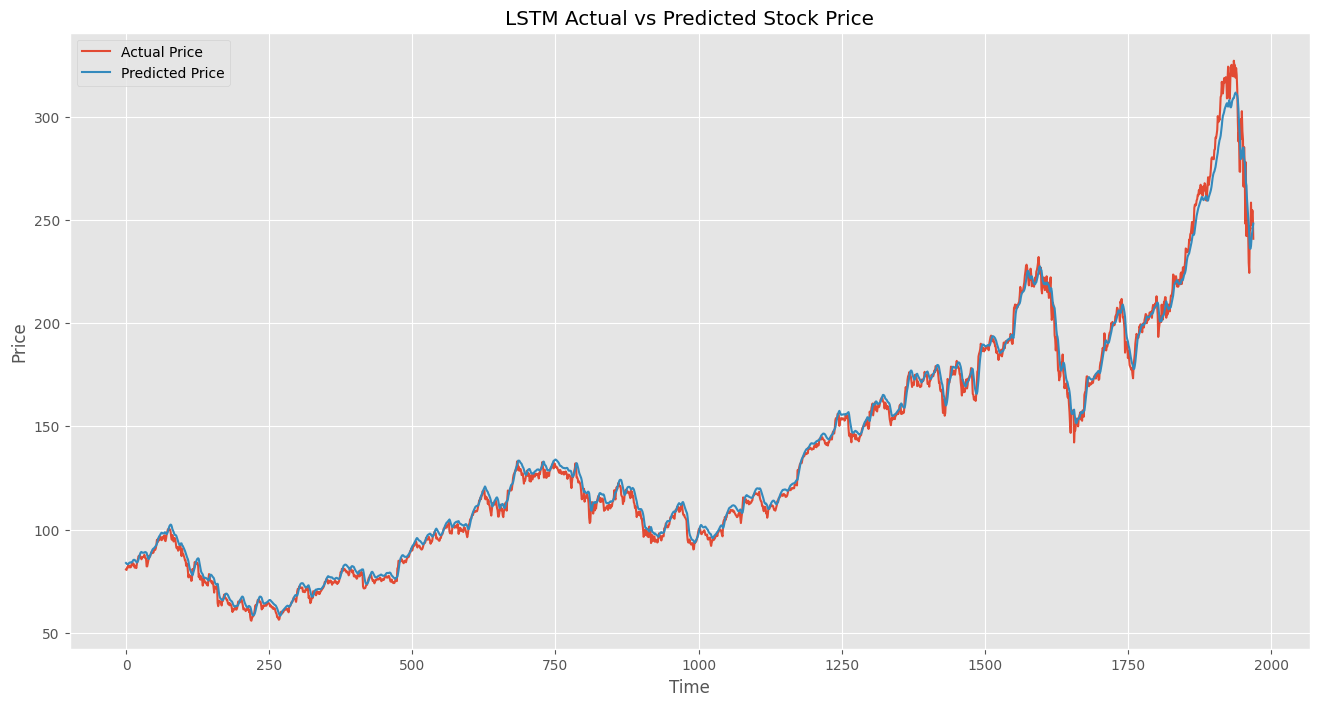

In [34]:
# Actual vs Predicted

plt.figure(figsize=(16,8))

plt.plot(
    y_test_actual,
    label='Actual Price'
)

plt.plot(
    predictions_lstm,
    label='Predicted Price'
)

plt.title('LSTM Actual vs Predicted Stock Price')

plt.xlabel('Time')

plt.ylabel('Price')

plt.legend()

plt.grid(True)

plt.savefig(
    "LSTM_Predictions.png",
    dpi=1080,
    bbox_inches='tight'
)

plt.show()


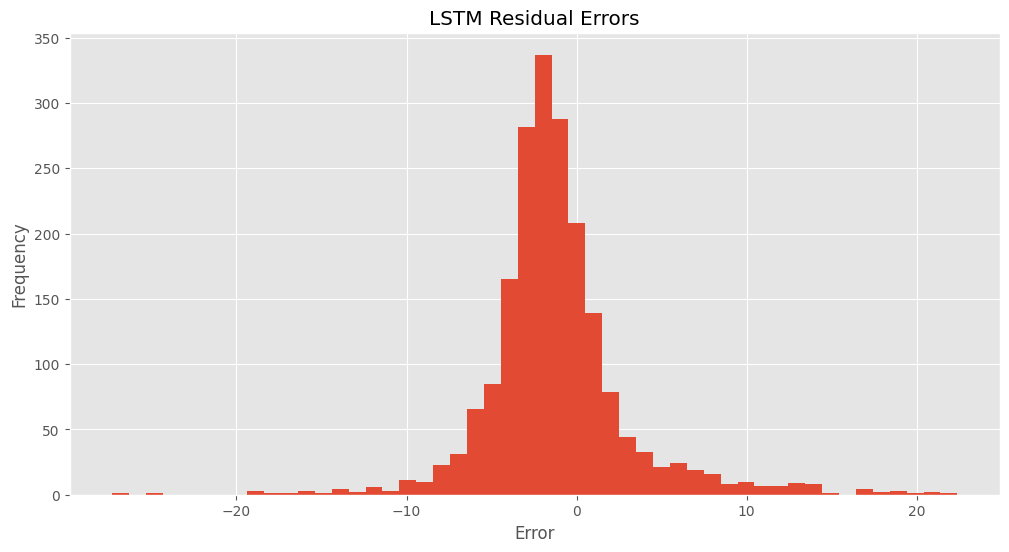

In [35]:
# Residual Error Plot


residuals = y_test_actual.flatten() - predictions_lstm.flatten()

plt.figure(figsize=(12,6))

plt.hist(
    residuals,
    bins=50
)

plt.title("LSTM Residual Errors")

plt.xlabel("Error")

plt.ylabel("Frequency")

plt.savefig(
    "LSTM_Residuals.png",
    dpi=1080,
    bbox_inches='tight'
)

plt.show()


In [36]:
# 17. GRU MODEL + COMPARISON
model_gru = Sequential([
    GRU(
        units=64,
        return_sequences=True,
        input_shape=(X_train.shape[1],1)
    ),

    Dropout(0.20),

    GRU(
        units=64,
        return_sequences=False
    ),

    Dropout(0.20),

    Dense(25),

    Dense(1)

])


In [37]:
# Compile Model

model_gru.compile(
    optimizer='adam',
    loss='mean_squared_error'
)

print("\nGRU Model Summary")

model_gru.summary()


GRU Model Summary


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 60, 64)         │        12,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 60, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 64)             │        24,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 25)             │         1,625 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            26 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 39,475 (154.20 KB)

 Trainable params: 39,475 (154.20 KB)

 Non-trainable params: 0 (0.00 B)

In [38]:
# Train GRU Model

start_time = time.time()

history_gru = model_gru.fit(
    X_train,
    y_train,
    validation_data=(X_test, y_test),
    epochs=50,
    batch_size=32,
    callbacks=[
        EarlyStopping(
            monitor='val_loss',
            patience=10,
            restore_best_weights=True
        )
    ],
    verbose=1
)

end_time = time.time()

gru_training_time = end_time - start_time

print("\nGRU Training Time")

print(gru_training_time)


Epoch 1/50
247/247 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - loss: 8.6326e-05 - val_loss: 1.9783e-04
Epoch 2/50
247/247 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 2.8235e-05 - val_loss: 0.0011
Epoch 3/50
247/247 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 2.7165e-05 - val_loss: 5.6053e-04
Epoch 4/50
247/247 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 2.7941e-05 - val_loss: 1.3022e-04
Epoch 5/50
247/247 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 2.4870e-05 - val_loss: 9.6688e-04
Epoch 6/50
247/247 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 2.2343e-05 - val_loss: 1.4112e-04
Epoch 7/50
247/247 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 2.2421e-05 - val_loss: 1.2293e-04
Epoch 8/50
247/247 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 2.3916e-05 - val_loss: 1.5073e-04
Epoch 9/50
247/247 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 1.9176e-05 - val_loss: 1.7462e-04
Epoch 10/50
247/247 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 1.9892e-05 - val_loss: 1.0789e-04
Epoch 11/50
247/247 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step

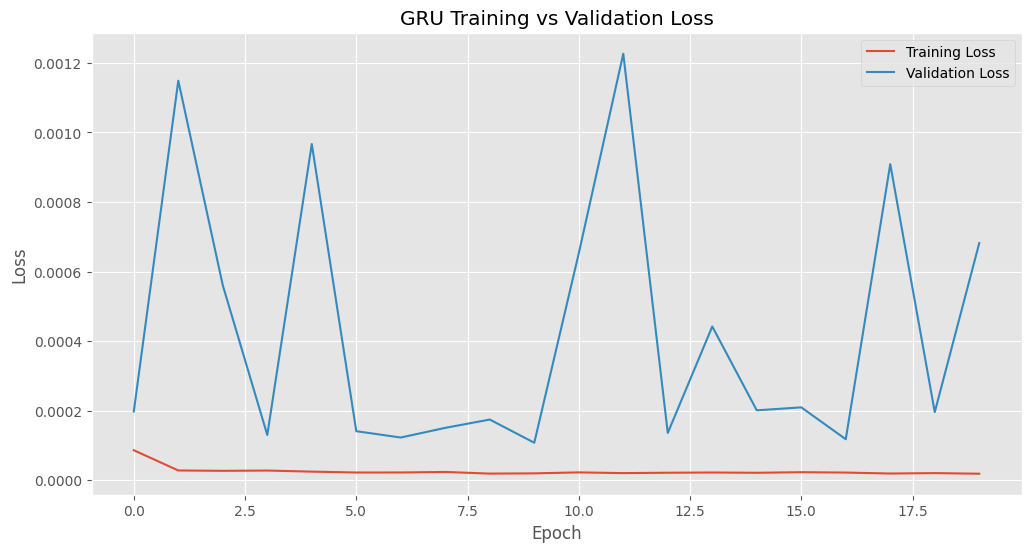

In [39]:
# Training Loss Graph

plt.figure(figsize=(12,6))

plt.plot(
    history_gru.history['loss'],
    label='Training Loss'
)

plt.plot(
    history_gru.history['val_loss'],
    label='Validation Loss'
)

plt.title('GRU Training vs Validation Loss')

plt.xlabel('Epoch')

plt.ylabel('Loss')

plt.legend()

plt.grid(True)

plt.savefig(
    "GRU_Loss_Curve.png",
    dpi=1080,
    bbox_inches='tight'
)

plt.show()

In [40]:
# GRU Predictions
predictions_gru = model_gru.predict(X_test)


62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step


In [41]:
# Reverse Scaling
predictions_gru = scaler.inverse_transform(
    predictions_gru
)

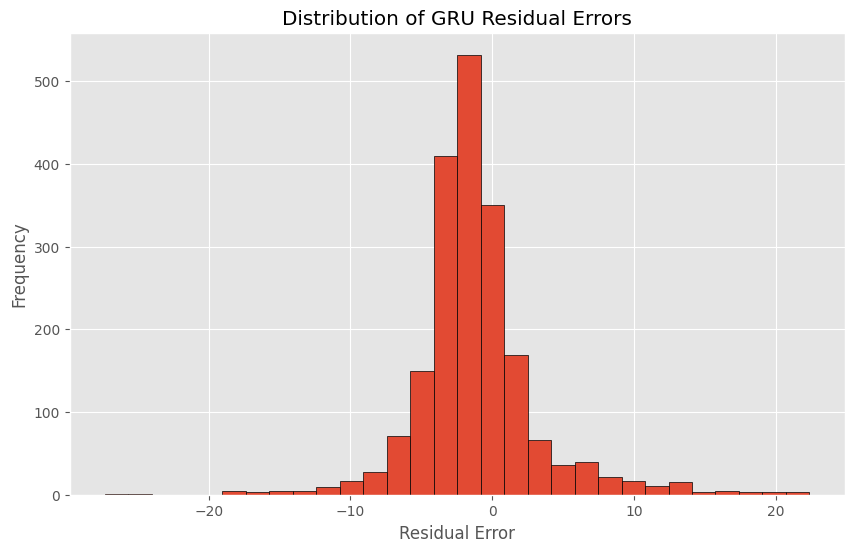

In [49]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.hist(residuals, bins=30, edgecolor='black')

plt.title('Distribution of GRU Residual Errors')
plt.xlabel('Residual Error')
plt.ylabel('Frequency')
plt.grid(True)
plt.savefig(
    "GRU Residual Errors.png",
    dpi=1080,
    bbox_inches='tight'
)
plt.show()

In [43]:
# Evaluation Metrics

rmse_gru = np.sqrt(
    mean_squared_error(
        y_test_actual,
        predictions_gru
    )
)

mae_gru = mean_absolute_error(
    y_test_actual,
    predictions_gru
)

r2_gru = r2_score(
    y_test_actual,
    predictions_gru
)


print("GRU RESULTS")

print("RMSE :", rmse_gru)
print("MAE  :", mae_gru)
print("R²   :", r2_gru)

GRU RESULTS
RMSE : 3.396587407904488
MAE  : 2.150686808164955
R²   : 0.9965412514049395


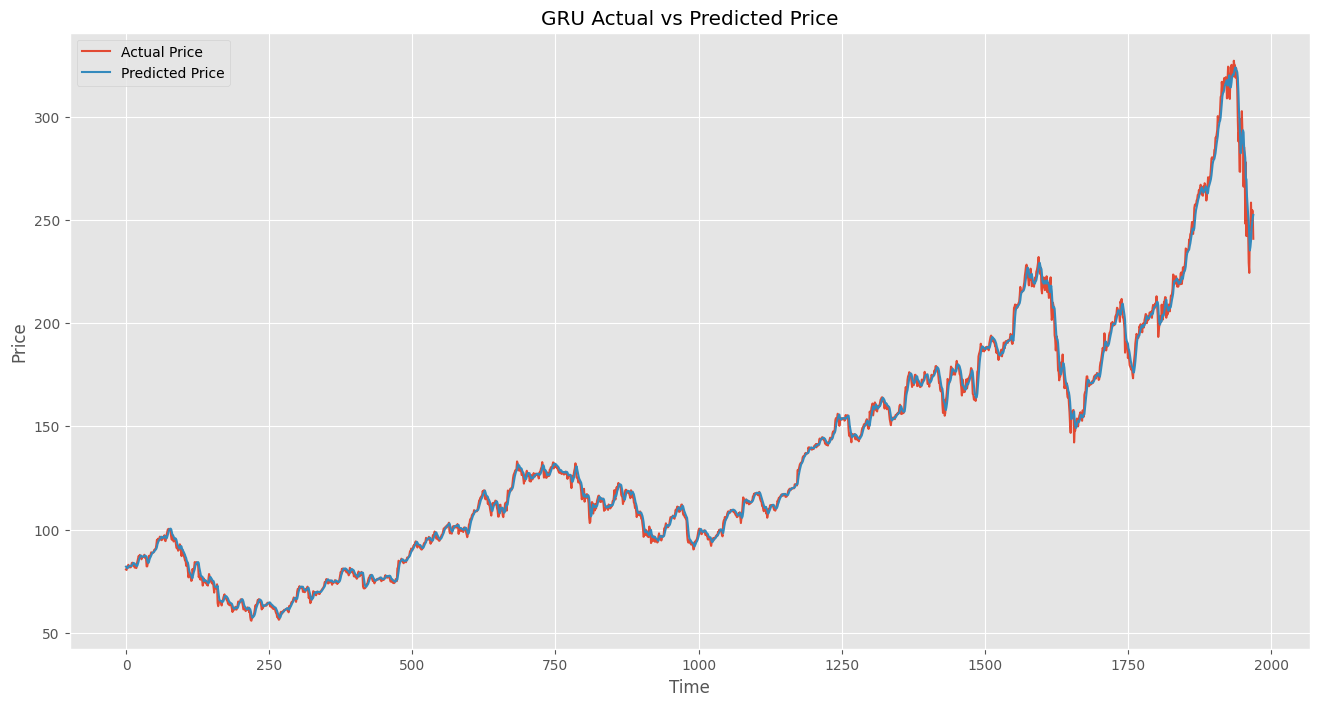

In [44]:
# Actual vs Predicted

plt.figure(figsize=(16,8))

plt.plot(
    y_test_actual,
    label='Actual Price'
)

plt.plot(
    predictions_gru,
    label='Predicted Price'
)

plt.title('GRU Actual vs Predicted Price')

plt.xlabel('Time')

plt.ylabel('Price')

plt.legend()

plt.grid(True)

plt.savefig(
    "GRU_Predictions.png",
    dpi=1080,
    bbox_inches='tight'
)

plt.show()

In [45]:
# Save GRU Model

model_gru.save(
    "GRU_Stock_Model.h5"
)

print("\nGRU Model Saved")


GRU Model Saved


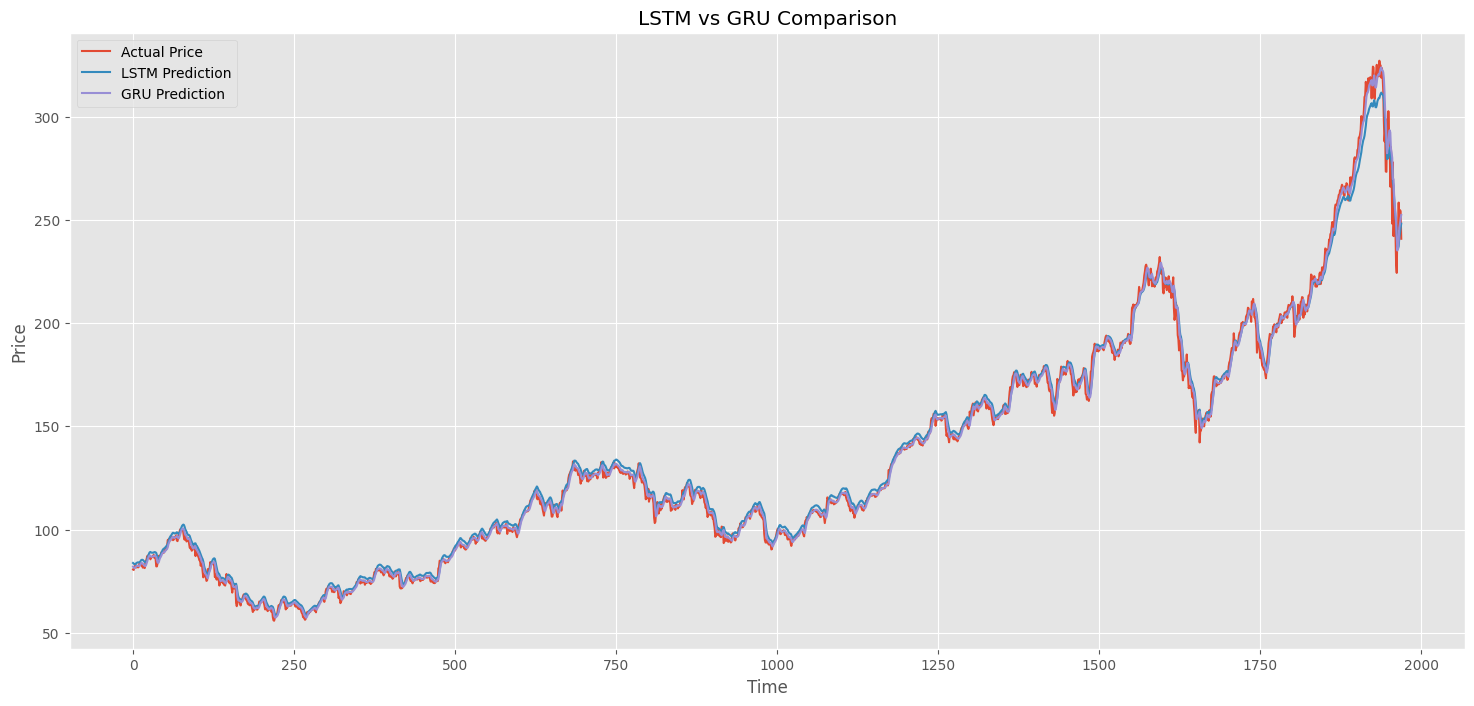

In [46]:
# LSTM vs GRU Prediction Graph

plt.figure(figsize=(18,8))

plt.plot(
    y_test_actual,
    label='Actual Price'
)

plt.plot(
    predictions_lstm,
    label='LSTM Prediction'
)

plt.plot(
    predictions_gru,
    label='GRU Prediction'
)

plt.title('LSTM vs GRU Comparison')

plt.xlabel('Time')

plt.ylabel('Price')

plt.legend()

plt.grid(True)

plt.savefig(
    "LSTM_vs_GRU.png",
    dpi=1080,
    bbox_inches='tight'
)

plt.show()


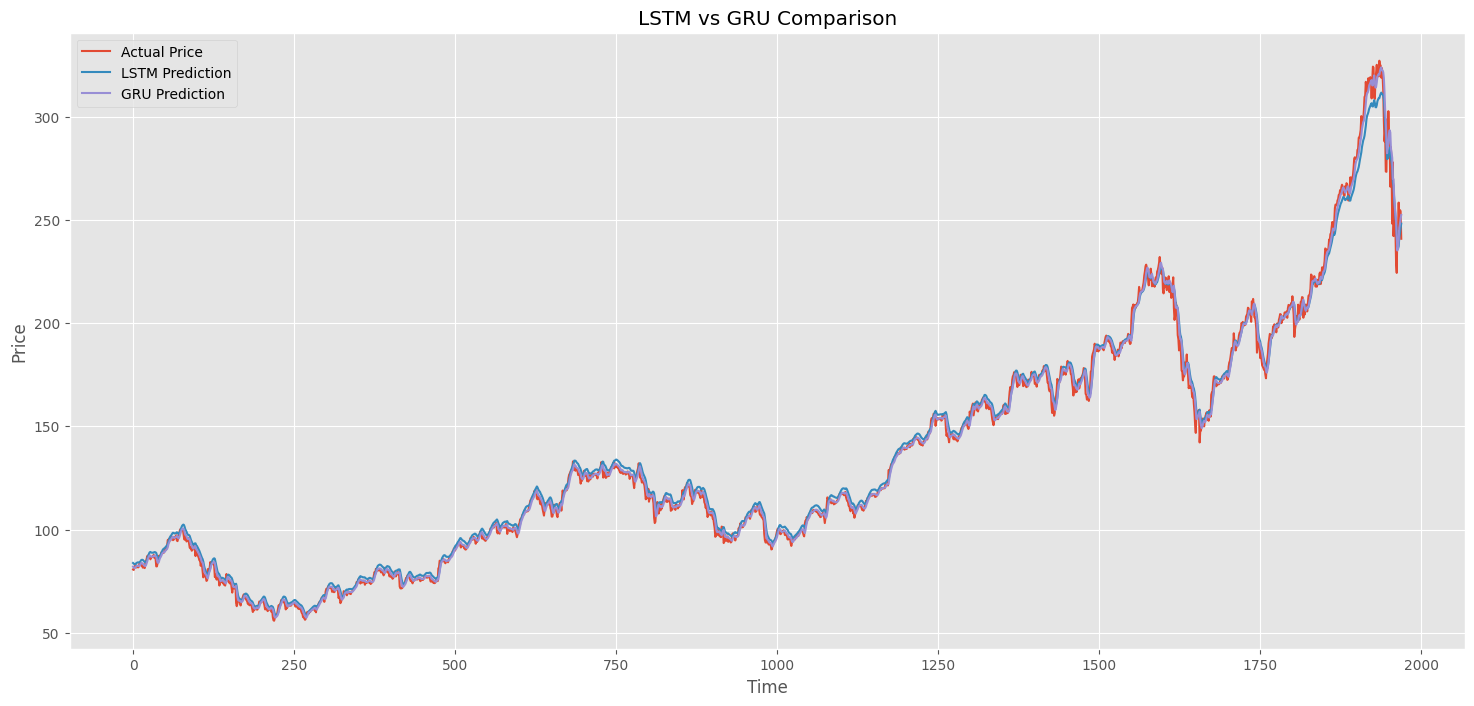

In [47]:
# LSTM vs GRU Prediction Graph


plt.figure(figsize=(18,8))

plt.plot(
    y_test_actual,
    label='Actual Price'
)

plt.plot(
    predictions_lstm,
    label='LSTM Prediction'
)

plt.plot(
    predictions_gru,
    label='GRU Prediction'
)

plt.title('LSTM vs GRU Comparison')

plt.xlabel('Time')

plt.ylabel('Price')

plt.legend()

plt.grid(True)

plt.savefig(
    "LSTM_vs_GRU.png",
    dpi=1080,
    bbox_inches='tight'
)

plt.show()


In [48]:
# Best Model

if rmse_lstm < rmse_gru:

    print("\nBest Performing Model : LSTM")

else:

    print("\nBest Performing Model : GRU")



Best Performing Model : GRU
